In [1]:
import scanpy as sc
import anndata as ad
import numpy as np
from matplotlib import rcParams

In [2]:
sc.settings.set_figure_params(dpi=50, facecolor="white")

### Process mouse bone marrow data

In [3]:
tm_bm1 = sc.read_10x_mtx('/Users/jprice/mooney/speciesOT/data/tabulamuris/droplet/Marrow-10X_P7_2')

In [4]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
tm_bm1.var["mt"] = tm_bm1.var_names.str.startswith("Mt-")
# ribosomal genes
tm_bm1.var["ribo"] = tm_bm1.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
tm_bm1.var["hb"] = tm_bm1.var_names.str.contains("^HB[^(P)]")

In [5]:
sc.pp.calculate_qc_metrics(
    tm_bm1, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

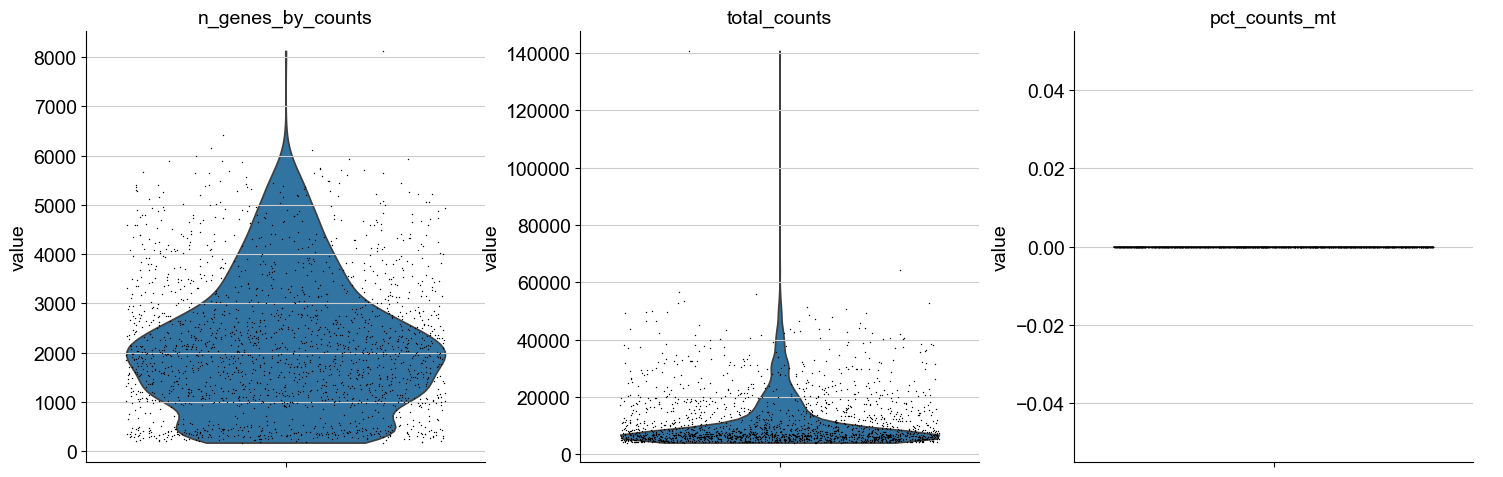

In [6]:
sc.pl.violin(
    tm_bm1,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

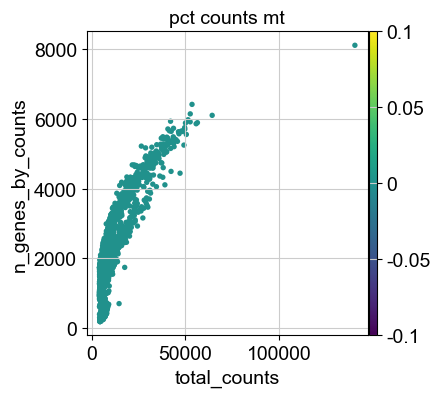

In [7]:
sc.pl.scatter(tm_bm1, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [8]:
sc.pp.filter_cells(tm_bm1, min_genes=100)
sc.pp.filter_genes(tm_bm1, min_cells=3)

In [9]:
tm_bm1.layers["counts"] = tm_bm1.X.copy()

In [10]:
tm_bm1.obs['sample'] = "a"

In [11]:
sc.pp.normalize_total(tm_bm1, target_sum=1e4)

In [12]:
sc.pp.log1p(tm_bm1)

In [13]:
sc.pp.highly_variable_genes(tm_bm1, min_mean=0.0125, max_mean=3, min_disp=0.5)

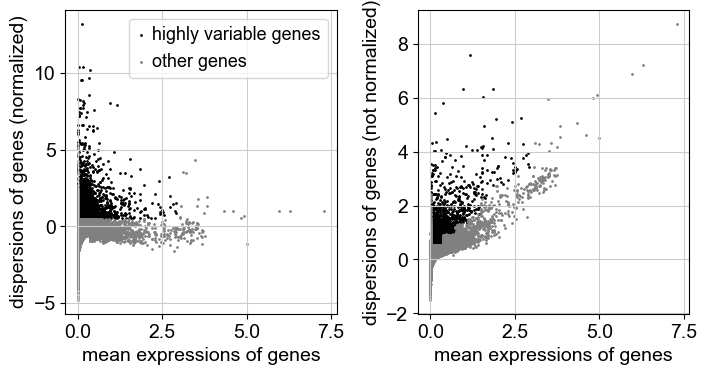

In [14]:
sc.pl.highly_variable_genes(tm_bm1)

In [15]:
sc.tl.pca(tm_bm1)

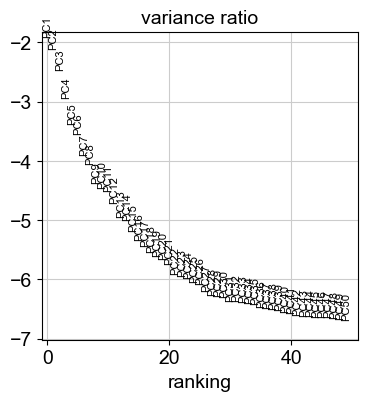

In [16]:
sc.pl.pca_variance_ratio(tm_bm1, n_pcs=50, log=True)

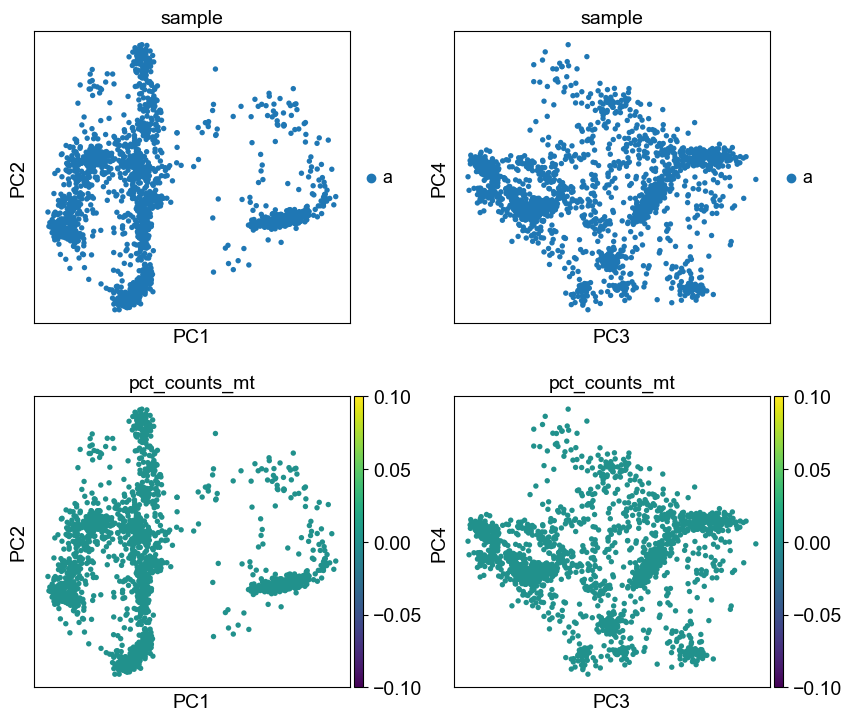

In [17]:
sc.pl.pca(
    tm_bm1,
    color=["sample", "sample", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
)

In [18]:
sc.pp.neighbors(tm_bm1)

In [19]:
sc.tl.umap(tm_bm1)

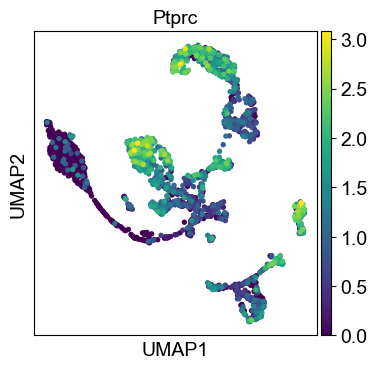

In [22]:
sc.pl.umap(
    tm_bm1,
    color="Ptprc"
)

In [27]:
sc.tl.leiden(tm_bm1, flavor="igraph", n_iterations=2)

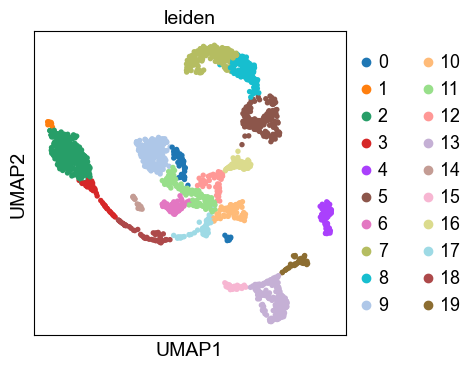

In [28]:
sc.pl.umap(tm_bm1, color=["leiden"])

In [29]:
tm_bm1

AnnData object with n_obs × n_vars = 1981 × 13403
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'sample', 'leiden'
    var: 'gene_ids', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'sample_colors', 'neighbors', 'umap', 'leiden', 'leiden_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

### Process human bone marrow data

In [30]:
ts_bm = sc.read('/Users/jprice/mooney/speciesOT/data/TS_Bone_Marrow.h5ad')

In [31]:
ts_bm

AnnData object with n_obs × n_vars = 12297 × 58870
    obs: 'organ_tissue', 'method', 'donor', 'anatomical_information', 'n_counts_UMIs', 'n_genes', 'cell_ontology_class', 'free_annotation', 'manually_annotated', 'compartment', 'gender'
    var: 'gene_symbol', 'feature_type', 'ensemblid', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: '_scvi', '_training_mode', 'cell_ontology_class_colors', 'dendrogram_cell_type_tissue', 'dendrogram_computational_compartment_assignment', 'dendrogram_consensus_prediction', 'dendrogram_tissue_cell_type', 'donor_colors', 'donor_method_colors', 'hvg', 'method_colors', 'neighbors', 'organ_tissue_colors', 'sex_colors', 'tissue_colors', 'umap'
    obsm: 'X_pca', 'X_scvi', 'X_scvi_umap', 'X_umap'
    layers: 'decontXcounts', 'raw_counts'
    obsp: 'connectivities', 'distances'

In [32]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
ts_bm.var["mt"] = ts_bm.var_names.str.startswith("MT-")
# ribosomal genes
ts_bm.var["ribo"] = ts_bm.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
ts_bm.var["hb"] = ts_bm.var_names.str.contains("^HB[^(P)]")

In [33]:
sc.pp.calculate_qc_metrics(
    ts_bm, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

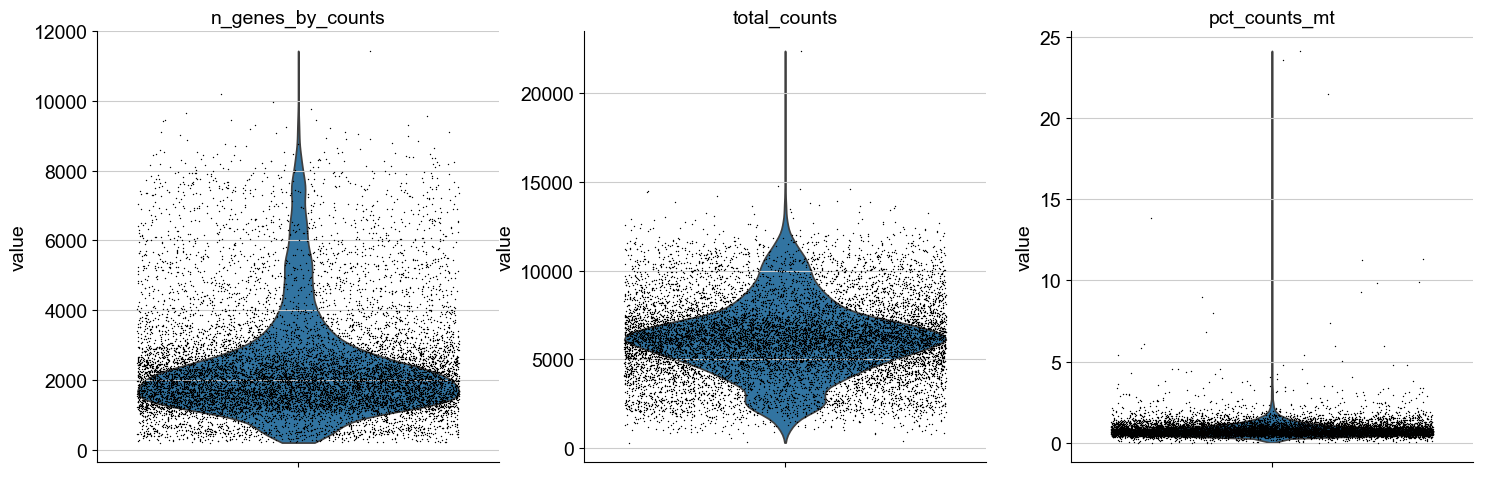

In [34]:
sc.pl.violin(
    ts_bm,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

In [35]:
sc.pp.filter_cells(ts_bm, min_genes=100)
sc.pp.filter_genes(ts_bm, min_cells=3)

In [36]:
ts_bm.layers["counts"] = ts_bm.X.copy()

In [37]:
sc.pp.normalize_total(ts_bm, target_sum=1e4)

In [38]:
sc.pp.log1p(ts_bm)

In [39]:
sc.pp.highly_variable_genes(ts_bm, n_top_genes=2000)

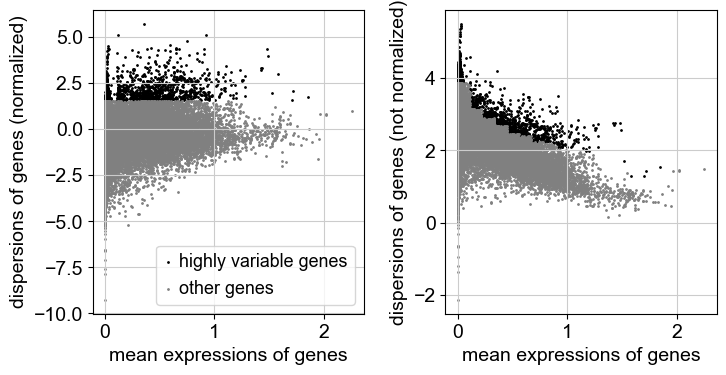

In [40]:
sc.pl.highly_variable_genes(ts_bm)

In [41]:
sc.tl.pca(ts_bm)

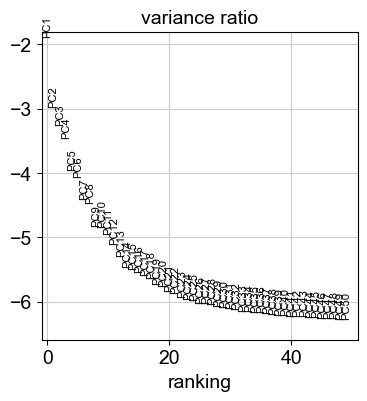

In [42]:
sc.pl.pca_variance_ratio(ts_bm, n_pcs=50, log=True)

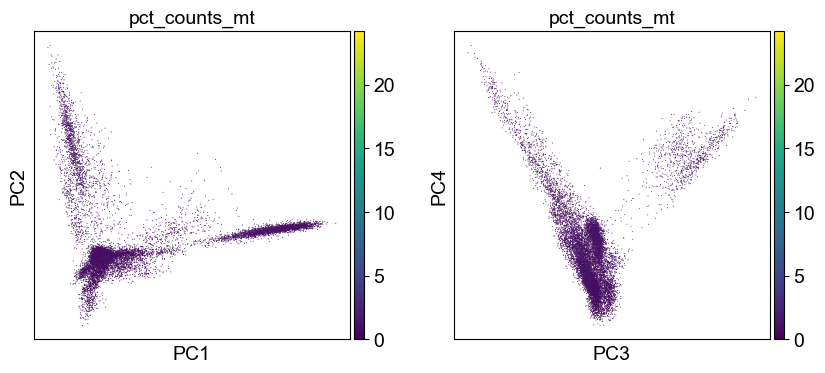

In [43]:
sc.pl.pca(
    ts_bm,
    color=["pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3)],
    ncols=2,
    size=2,
)

In [44]:
sc.pp.neighbors(ts_bm)

In [45]:
sc.tl.umap(ts_bm)

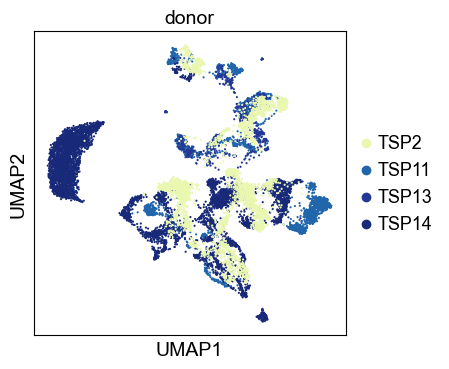

In [46]:
sc.pl.umap(
    ts_bm,
    color="donor",
)

In [47]:
# Using the igraph implementation and a fixed number of iterations can be significantly faster, especially for larger datasets
sc.tl.leiden(ts_bm, flavor="igraph", n_iterations=2)

In [48]:
FIGSIZE = (12, 12)
rcParams["figure.figsize"] = FIGSIZE

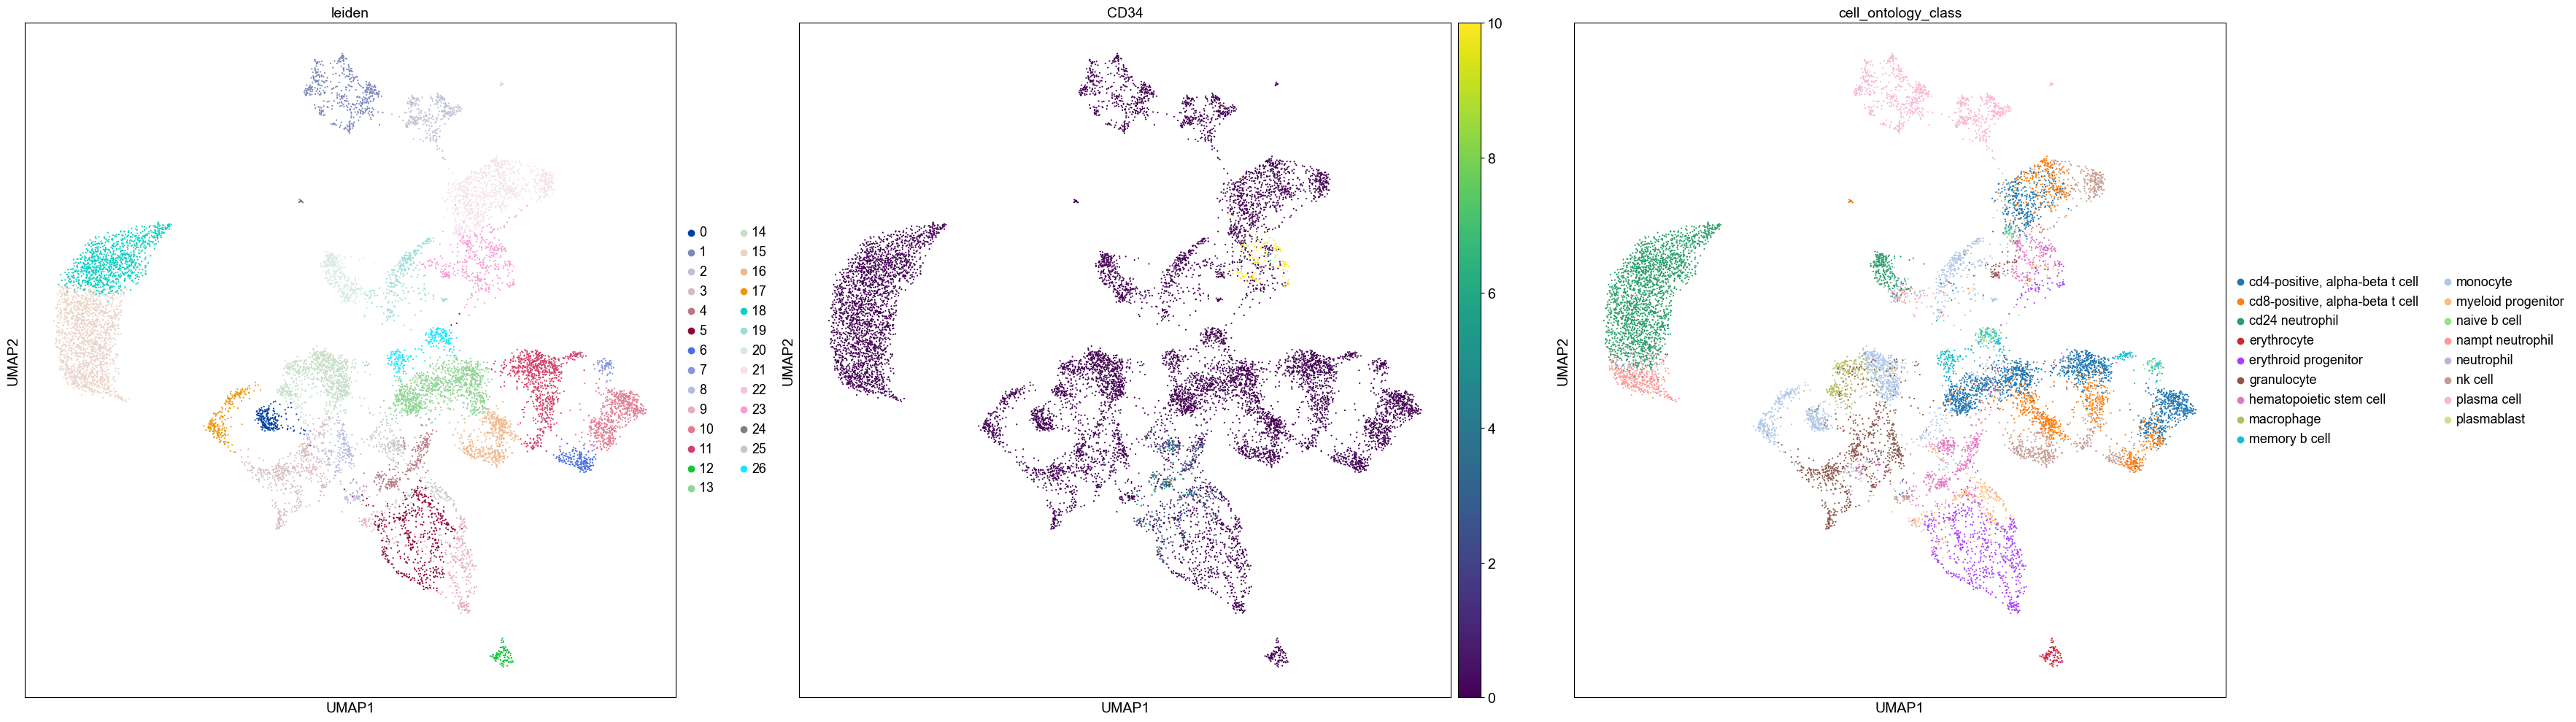

In [49]:
sc.pl.umap(ts_bm, color=["leiden",'CD34','cell_ontology_class'],vmax=10)

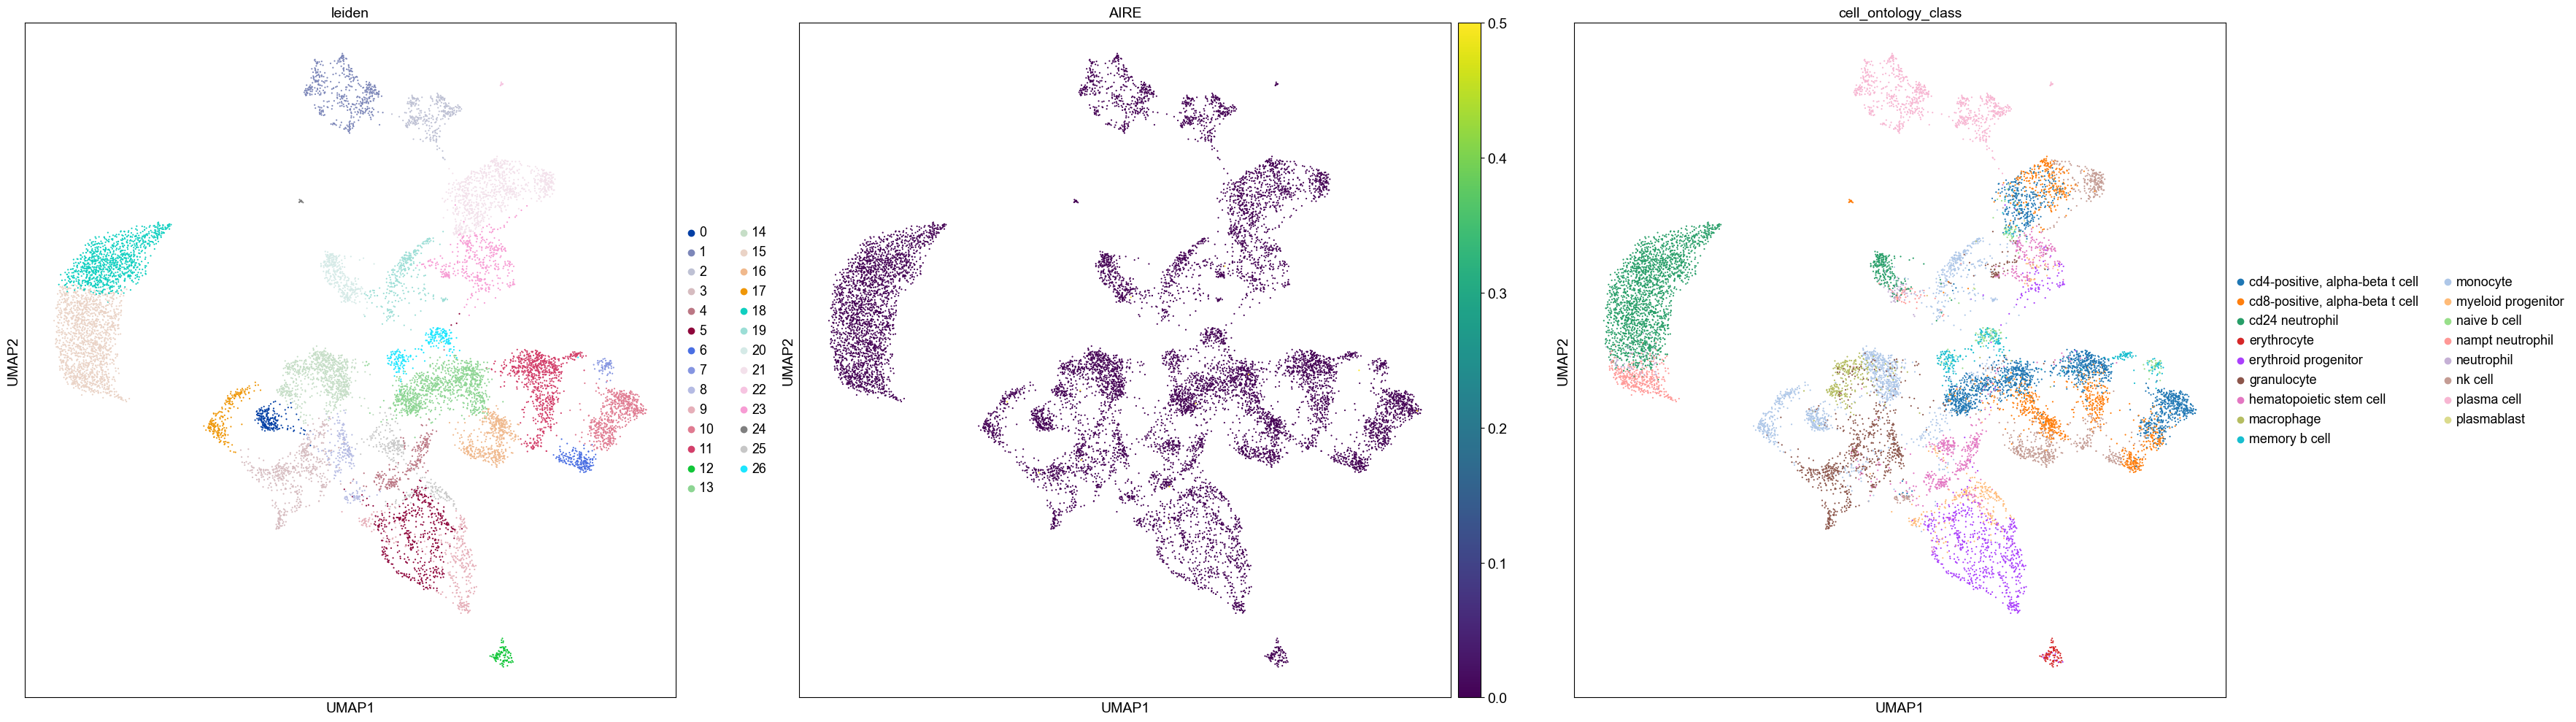

In [55]:
sc.pl.umap(ts_bm, color=["leiden",'AIRE','cell_ontology_class'],vmax=0.5)